In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('01_DiatomInventories_GTstudentproject_B.csv')
valores_nulos= df.isnull().sum()
valores_nulos

TaxonName                           0
TaxonCode                           0
SamplingOperations_code             0
CodeSite_SamplingOperations         0
Date_SamplingOperation              0
Abundance_nbcell                    0
TotalAbundance_SamplingOperation    0
Abundance_pm                        0
dtype: int64

In [3]:
cuantitativas= df.select_dtypes(include=["number"])
cualitativas = df.select_dtypes(include=["object", "category"])

<Figure size 1500x800 with 0 Axes>

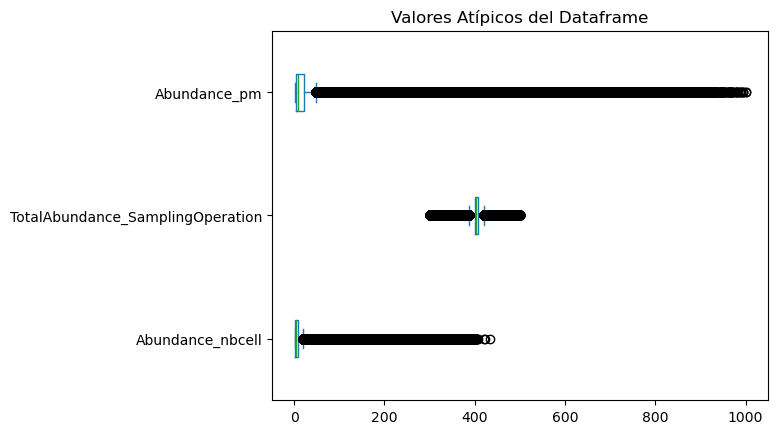

In [4]:
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show()

In [5]:
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Abundance_nbcell                     94.948382
TotalAbundance_SamplingOperation    437.096025
Abundance_pm                        233.878730
dtype: float64
Limite inferior permitido Abundance_nbcell                    -71.124054
TotalAbundance_SamplingOperation    374.808697
Abundance_pm                       -175.176372
dtype: float64


In [6]:
data3= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,8.0,420.0,19.047619
1,1.0,404.0,2.475248
2,1.0,400.0,2.500000
3,2.0,400.0,5.000000
4,1.0,400.0,2.500000
...,...,...,...
1643867,1.0,412.0,2.427184
1643868,1.0,400.0,2.500000
1643869,1.0,403.0,2.481390
1643870,7.0,400.0,17.500000


In [7]:
valores_nulos=data3.isnull().sum()
valores_nulos

Abundance_nbcell                    37619
TotalAbundance_SamplingOperation    34628
Abundance_pm                        37352
dtype: int64

In [8]:
data_clean=data3.copy()
data_clean=data_clean.fillna(round(data3.median(),1))
data_clean

,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,8.0,420.0,19.047619
1,1.0,404.0,2.475248
2,1.0,400.0,2.500000
3,2.0,400.0,5.000000
4,1.0,400.0,2.500000
...,...,...,...
1643867,1.0,412.0,2.427184
1643868,1.0,400.0,2.500000
1643869,1.0,403.0,2.481390
1643870,7.0,400.0,17.500000


In [9]:
valores_nulos=data_clean.isnull().sum()
valores_nulos

Abundance_nbcell                    0
TotalAbundance_SamplingOperation    0
Abundance_pm                        0
dtype: int64

In [10]:
Datos_limpios = pd.concat([cualitativas, data_clean], axis=1)
Datos_limpios

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8.0,420.0,19.047619
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1.0,404.0,2.475248
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1.0,400.0,2.500000
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2.0,400.0,5.000000
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...
1643867,Zygoceros surirella,Zygsu01,S03231260_20130806,S03231260,2013-08-06,1.0,412.0,2.427184
1643868,Zygoceros surirella,Zygsu01,S03269295_20110804,S03269295,2011-08-04,1.0,400.0,2.500000
1643869,Zygoceros surirella,Zygsu01,S05076010_20120606,S05076010,2012-06-06,1.0,403.0,2.481390
1643870,Zygoceros surirella,Zygsu01,S05076010_20220831,S05076010,2022-08-31,7.0,400.0,17.500000


In [11]:
Datos_limpios.head(10)

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8.0,420.0,19.047619
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1.0,404.0,2.475248
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1.0,400.0,2.500000
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2.0,400.0,5.000000
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1.0,400.0,2.500000
5,Achnanthes affinis,Achaf01,S02096900_20080910,S02096900,2008-09-10,34.0,400.0,85.000000
6,Achnanthes affinis,Achaf01,S02096950_20070911,S02096950,2007-09-11,1.0,400.0,2.500000
7,Achnanthes affinis,Achaf01,S02107870_20080723,S02107870,2008-07-23,1.0,400.0,2.500000
8,Achnanthes affinis,Achaf01,S02110650_20080730,S02110650,2008-07-30,1.0,400.0,2.500000
9,Achnanthes affinis,Achaf01,S02115950_20070802,S02115950,2007-08-02,2.0,400.0,5.000000


In [12]:
Tabla_freq = Datos_limpios['TaxonName'].value_counts().reset_index()
Tabla_freq

,TaxonName,count
0,Achnanthes minutissima,43691
1,Amphora pediculus,39209
2,Cocconeis euglypta,38570
3,Sellaphora nigri,38039
4,Navicula cryptotenella,37723
...,...,...
2287,Navicula follis,1
2288,Navicula gastrum,1
2289,Navicula geitleri,1
2290,Navicula germanopolonica,1


In [13]:
pd.options.display.max_rows = None
Tabla_freq.head(17)

,TaxonName,count
0,Achnanthes minutissima,43691
1,Amphora pediculus,39209
2,Cocconeis euglypta,38570
3,Sellaphora nigri,38039
4,Navicula cryptotenella,37723
5,Nitzschia dissipata,34461
6,Vibrio tripunctatus,30899
7,Rhoicosphenia abbreviata,30560
8,Navicula permitis,29789
9,Achnanthes lanceolata,27239


In [14]:
Filtro= Tabla_freq[Tabla_freq['count']>20578]
Filtro

,TaxonName,count
0,Achnanthes minutissima,43691
1,Amphora pediculus,39209
2,Cocconeis euglypta,38570
3,Sellaphora nigri,38039
4,Navicula cryptotenella,37723
5,Nitzschia dissipata,34461
6,Vibrio tripunctatus,30899
7,Rhoicosphenia abbreviata,30560
8,Navicula permitis,29789
9,Achnanthes lanceolata,27239


In [15]:
Filtro_index= Filtro.set_index('TaxonName')
Filtro_index

,count
TaxonName,
Achnanthes minutissima,43691
Amphora pediculus,39209
Cocconeis euglypta,38570
Sellaphora nigri,38039
Navicula cryptotenella,37723
Nitzschia dissipata,34461
Vibrio tripunctatus,30899
Rhoicosphenia abbreviata,30560
Navicula permitis,29789


Text(0, 0.5, 'Frecuencia')

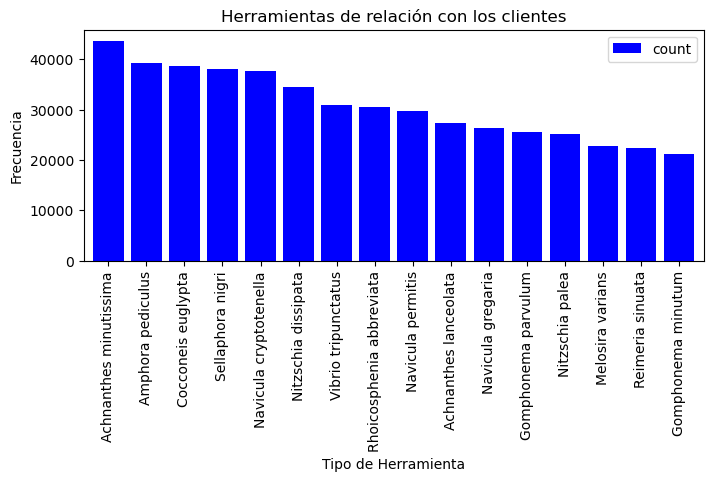

In [16]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(8,3), color= "Blue")
plt.title('Herramientas de relación con los clientes')
plt.xlabel('Tipo de Herramienta')
plt.ylabel('Frecuencia')

In [17]:
Tabla_freq2 = Datos_limpios['TaxonCode'].value_counts().reset_index()
Tabla_freq2
pd.options.display.max_rows = None
Tabla_freq2.head(17)

,TaxonCode,count
0,Achmi02,43691
1,Amppe02,39209
2,Coceu01,38570
3,Selni01,38039
4,Navcr09,37723
5,Nitdi04,34461
6,Vibtr01,30899
7,Rhoab01,30560
8,Navpe05,29789
9,Achla02,27239


In [18]:
Filtro2= Tabla_freq2[Tabla_freq2['count']>20578]
Filtro2

,TaxonCode,count
0,Achmi02,43691
1,Amppe02,39209
2,Coceu01,38570
3,Selni01,38039
4,Navcr09,37723
5,Nitdi04,34461
6,Vibtr01,30899
7,Rhoab01,30560
8,Navpe05,29789
9,Achla02,27239


In [19]:
Filtro_index2= Filtro2.set_index('TaxonCode')
Filtro_index2

,count
TaxonCode,
Achmi02,43691
Amppe02,39209
Coceu01,38570
Selni01,38039
Navcr09,37723
Nitdi04,34461
Vibtr01,30899
Rhoab01,30560
Navpe05,29789


<Axes: xlabel='TaxonCode'>

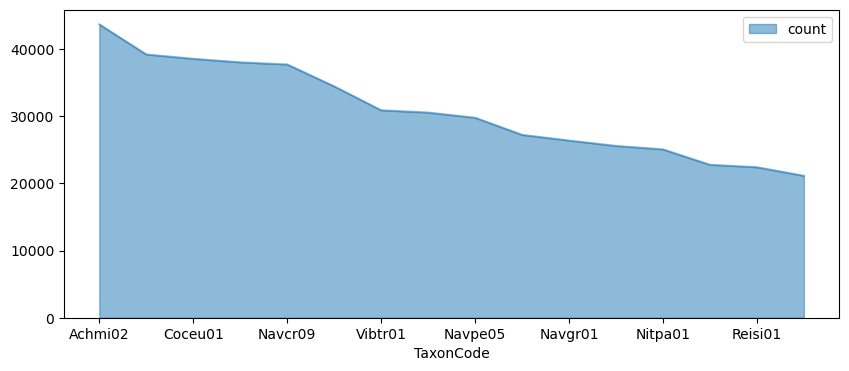

In [20]:
Filtro_index2.plot(kind='area', figsize=(10,4),alpha = 0.5)

In [21]:
Tabla_freq3 = Datos_limpios['SamplingOperations_code'].value_counts().reset_index()
Tabla_freq3
pd.options.display.max_rows = None
Tabla_freq3.head(17)

,SamplingOperations_code,count
0,S05119000_20160627,97
1,S05051000_20080722,97
2,S05068700_20070904,94
3,S04215520_20200702,92
4,S04304002_20200907,92
5,S04103550_20150811,92
6,S04615008_20130719,91
7,S03132260_20120718,91
8,S04103935_20200929,89
9,S04473008_20160711,89


In [22]:
Filtro3= Tabla_freq3[Tabla_freq3['count']>86]
Filtro3

,SamplingOperations_code,count
0,S05119000_20160627,97
1,S05051000_20080722,97
2,S05068700_20070904,94
3,S04215520_20200702,92
4,S04304002_20200907,92
5,S04103550_20150811,92
6,S04615008_20130719,91
7,S03132260_20120718,91
8,S04103935_20200929,89
9,S04473008_20160711,89


In [23]:
Filtro_index3= Filtro3.set_index('SamplingOperations_code')
Filtro_index3

,count
SamplingOperations_code,
S05119000_20160627,97
S05051000_20080722,97
S05068700_20070904,94
S04215520_20200702,92
S04304002_20200907,92
S04103550_20150811,92
S04615008_20130719,91
S03132260_20120718,91
S04103935_20200929,89


<Axes: xlabel='SamplingOperations_code'>

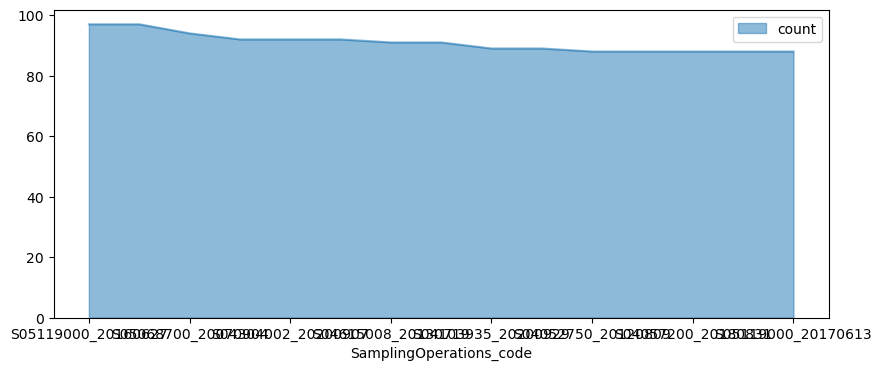

In [24]:
Filtro_index3.plot(kind='area', figsize=(10,4),alpha = 0.5)

In [25]:
Tabla_freq4 = Datos_limpios['Date_SamplingOperation'].value_counts().reset_index()
Tabla_freq4
pd.options.display.max_rows = None
Tabla_freq4.head(10)

,Date_SamplingOperation,count
0,2013-07-11,4545
1,2013-07-17,4431
2,2013-07-16,4401
3,2015-07-08,4376
4,2018-07-17,4278
5,2015-06-24,4126
6,2012-07-25,4091
7,2012-07-24,3833
8,2016-07-21,3742
9,2016-07-20,3706


In [26]:
Filtro4= Tabla_freq4[Tabla_freq4['count']>3706]
Filtro4

,Date_SamplingOperation,count
0,2013-07-11,4545
1,2013-07-17,4431
2,2013-07-16,4401
3,2015-07-08,4376
4,2018-07-17,4278
5,2015-06-24,4126
6,2012-07-25,4091
7,2012-07-24,3833
8,2016-07-21,3742


In [27]:
Filtro_index4= Filtro4.set_index('Date_SamplingOperation')
Filtro_index4

,count
Date_SamplingOperation,
2013-07-11,4545
2013-07-17,4431
2013-07-16,4401
2015-07-08,4376
2018-07-17,4278
2015-06-24,4126
2012-07-25,4091
2012-07-24,3833
2016-07-21,3742


<Axes: ylabel='count'>

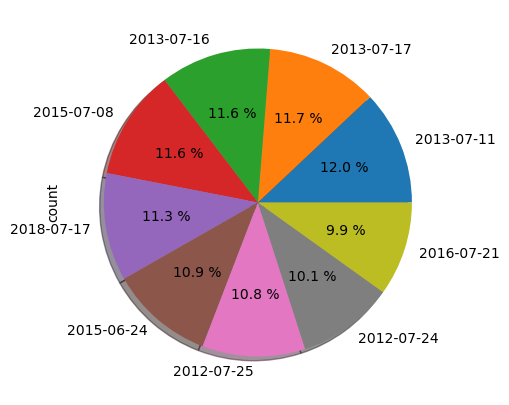

In [28]:
#Realizamos grafico de pastel del dataframe filtrado
Filtro_index4["count"].plot(kind='pie', figsize=(10,5), shadow=True, autopct="%0.1f %%")

In [29]:
Datos_limpios['Abundance_nbcell'].info()
n=1643871

<class 'pandas.core.series.Series'>
RangeIndex: 1643872 entries, 0 to 1643871
Series name: Abundance_nbcell
Non-Null Count    Dtype  
--------------    -----  
1643872 non-null  float64
dtypes: float64(1)
memory usage: 12.5 MB


In [30]:
Max = Datos_limpios['Abundance_nbcell'].max()
Min = Datos_limpios['Abundance_nbcell'].min()
Limites = [Min, Max]
Limites

[1.0, 94.0]

In [31]:
R=Max-Min
R

93.0

In [32]:
ni = 1+3.32*np.log10(n)
ni

np.float64(21.63668087693074)

In [33]:
i=R/ni
i

np.float64(4.298256305067456)

In [34]:
intervalos = np.linspace(0.9, 94.1, 22)
categorias = [f"Categoría{i+1} ({round(intervalos[i],2)} a {round(intervalos[i+1],2)})" for i in range(len(intervalos)-1)]
categorias

['Categoría1 (0.9 a 5.34)',
 'Categoría2 (5.34 a 9.78)',
 'Categoría3 (9.78 a 14.21)',
 'Categoría4 (14.21 a 18.65)',
 'Categoría5 (18.65 a 23.09)',
 'Categoría6 (23.09 a 27.53)',
 'Categoría7 (27.53 a 31.97)',
 'Categoría8 (31.97 a 36.4)',
 'Categoría9 (36.4 a 40.84)',
 'Categoría10 (40.84 a 45.28)',
 'Categoría11 (45.28 a 49.72)',
 'Categoría12 (49.72 a 54.16)',
 'Categoría13 (54.16 a 58.6)',
 'Categoría14 (58.6 a 63.03)',
 'Categoría15 (63.03 a 67.47)',
 'Categoría16 (67.47 a 71.91)',
 'Categoría17 (71.91 a 76.35)',
 'Categoría18 (76.35 a 80.79)',
 'Categoría19 (80.79 a 85.22)',
 'Categoría20 (85.22 a 89.66)',
 'Categoría21 (89.66 a 94.1)']

In [35]:
Datos_limpios['TotalAbundance_SamplingOperation'].info()
n1=1643871

<class 'pandas.core.series.Series'>
RangeIndex: 1643872 entries, 0 to 1643871
Series name: TotalAbundance_SamplingOperation
Non-Null Count    Dtype  
--------------    -----  
1643872 non-null  float64
dtypes: float64(1)
memory usage: 12.5 MB


In [36]:
Max1 = Datos_limpios['TotalAbundance_SamplingOperation'].max()
Min1 = Datos_limpios['TotalAbundance_SamplingOperation'].min()
Limites1 = [Min1, Max1]
Limites1

[375.0, 437.0]

In [37]:
R1=Max1-Min1
R1

62.0

In [38]:
ni1 = 1+3.32*np.log10(n1)
ni1

np.float64(21.63668087693074)

In [39]:
i1=R1/ni1
i1

np.float64(2.865504203378304)

In [40]:
intervalos1 =np.linspace(374.9, 437.1,22)
categorias1 = [f"Categoría{i+1} ({round(intervalos[i],2)} a {round(intervalos[i+1],2)})" for i in range(len(intervalos)-1)]
categorias1

['Categoría1 (0.9 a 5.34)',
 'Categoría2 (5.34 a 9.78)',
 'Categoría3 (9.78 a 14.21)',
 'Categoría4 (14.21 a 18.65)',
 'Categoría5 (18.65 a 23.09)',
 'Categoría6 (23.09 a 27.53)',
 'Categoría7 (27.53 a 31.97)',
 'Categoría8 (31.97 a 36.4)',
 'Categoría9 (36.4 a 40.84)',
 'Categoría10 (40.84 a 45.28)',
 'Categoría11 (45.28 a 49.72)',
 'Categoría12 (49.72 a 54.16)',
 'Categoría13 (54.16 a 58.6)',
 'Categoría14 (58.6 a 63.03)',
 'Categoría15 (63.03 a 67.47)',
 'Categoría16 (67.47 a 71.91)',
 'Categoría17 (71.91 a 76.35)',
 'Categoría18 (76.35 a 80.79)',
 'Categoría19 (80.79 a 85.22)',
 'Categoría20 (85.22 a 89.66)',
 'Categoría21 (89.66 a 94.1)']

In [41]:
Datos_limpios['Abundance_pm'].info()
n2=1643871

<class 'pandas.core.series.Series'>
RangeIndex: 1643872 entries, 0 to 1643871
Series name: Abundance_pm
Non-Null Count    Dtype  
--------------    -----  
1643872 non-null  float64
dtypes: float64(1)
memory usage: 12.5 MB


In [42]:
Max2 = Datos_limpios['Abundance_pm'].max()
Min2 = Datos_limpios['Abundance_pm'].min()
Limites2 = [Min2, Max2]
Limites2

[2.0, 233.85300668151447]

In [43]:
R2=Max2-Min2
R2

231.85300668151447

In [44]:
ni2 = 1+3.32*np.log10(n2)
ni2

np.float64(21.63668087693074)

In [45]:
i2=R2/ni2
i2

np.float64(10.71573814857706)

In [46]:
intervalos2 =np.linspace(1.9, 233.9,22)
categorias2 = [f"Categoría{i+1} ({round(intervalos[i],2)} a {round(intervalos[i+1],2)})" for i in range(len(intervalos)-1)]
categorias2

['Categoría1 (0.9 a 5.34)',
 'Categoría2 (5.34 a 9.78)',
 'Categoría3 (9.78 a 14.21)',
 'Categoría4 (14.21 a 18.65)',
 'Categoría5 (18.65 a 23.09)',
 'Categoría6 (23.09 a 27.53)',
 'Categoría7 (27.53 a 31.97)',
 'Categoría8 (31.97 a 36.4)',
 'Categoría9 (36.4 a 40.84)',
 'Categoría10 (40.84 a 45.28)',
 'Categoría11 (45.28 a 49.72)',
 'Categoría12 (49.72 a 54.16)',
 'Categoría13 (54.16 a 58.6)',
 'Categoría14 (58.6 a 63.03)',
 'Categoría15 (63.03 a 67.47)',
 'Categoría16 (67.47 a 71.91)',
 'Categoría17 (71.91 a 76.35)',
 'Categoría18 (76.35 a 80.79)',
 'Categoría19 (80.79 a 85.22)',
 'Categoría20 (85.22 a 89.66)',
 'Categoría21 (89.66 a 94.1)']